In [1]:
import numpy as np 
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd

df = pd.read_csv('./housing 2.csv')


2024-01-01 23:30:06.589837: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [3]:
df = df.dropna()

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


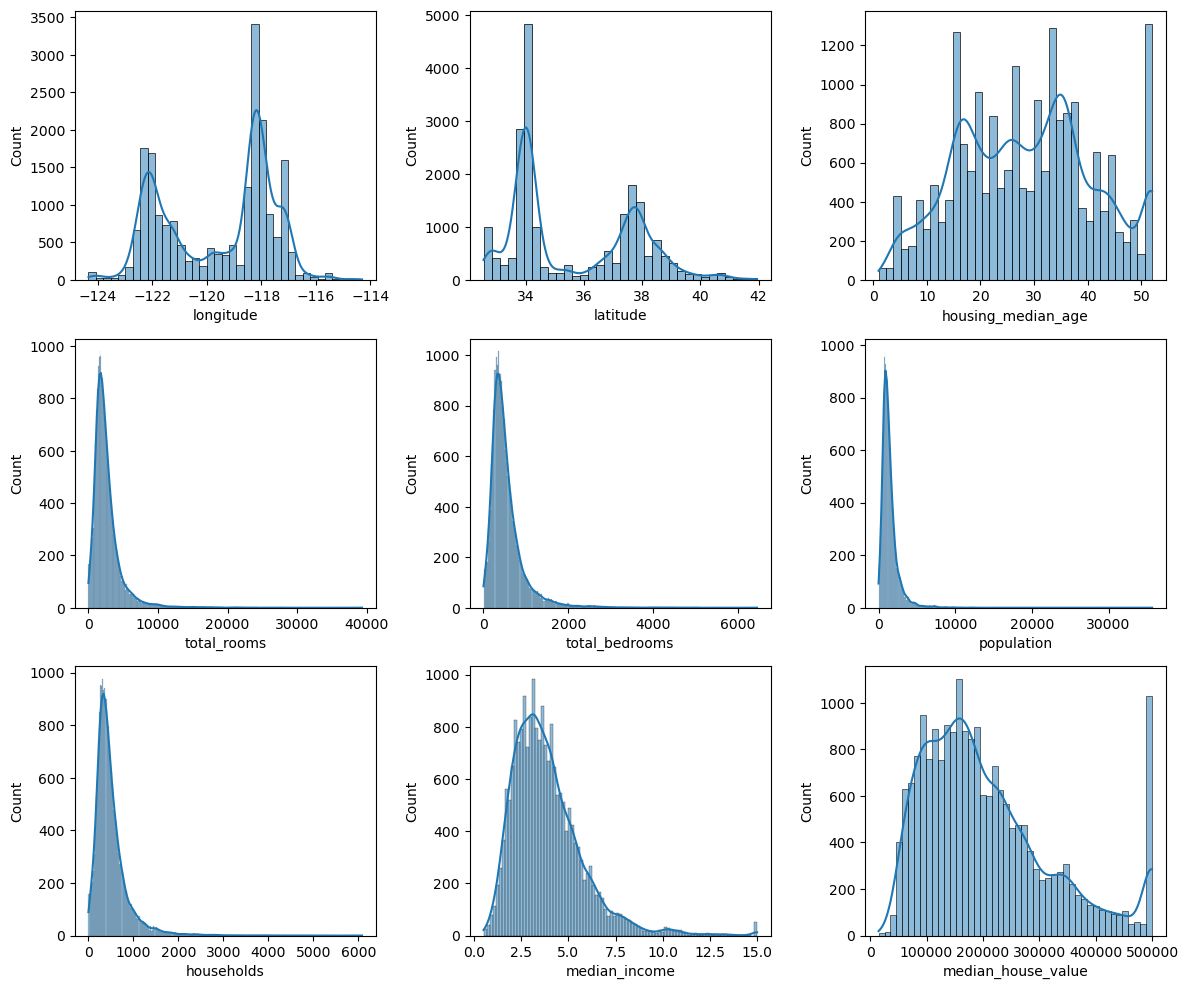

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

fig , axs = plt.subplots(3,3, figsize = (12,10) )
axs = axs.flatten()

for i, column in enumerate(df.columns[:-1]):
    sns.histplot(ax = axs[i], data = df , x = column, kde=True)
    axs[i].set_xlabel(column)
    
plt.tight_layout()
plt.show()

In [6]:
df['rooms'] = df['total_rooms']  / df['population']
df['bedrooms'] = df['total_bedrooms'] / df['population']
df["avg_household"] = df['households'] / df['population']
df= df.drop(['population', 'total_rooms', 'total_bedrooms','households'  ] , axis = 1)

In [7]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [8]:
#analyze house ocean_proximity affects house value
nearbay_price = df[df['ocean_proximity'] == 'NEAR BAY']['median_house_value'].mean()
inland_price = df[df['ocean_proximity']=='INLAND']['median_house_value'].mean()
ocean_price = df[df['ocean_proximity']=='<1H OCEAN']['median_house_value'].mean()
nearocean_price = df[df['ocean_proximity']=='NEAR OCEAN']['median_house_value'].mean()
island_price = df[df['ocean_proximity']=='ISLAND']['median_house_value'].mean()

In [9]:
print(f'nearbay_price:{nearbay_price}')
print(f"inland_price: {inland_price}" )
print(f"oceanland_price {ocean_price}" )
print(f"nearocean_price {nearocean_price}" )
print(f"island_price {island_price}" )
#

nearbay_price:259279.29207048457
inland_price: 124896.86314655172
oceanland_price 240267.99081248615
nearocean_price 249042.35502283106
island_price 380440.0


In [10]:
'''
We can see <1H OCEAN and Near ocean shows has approximetlly equal effects for prices. 
This make sense b/c <1H Ocean means it is near to the ocean
'''
print((nearbay_price / inland_price).round(2))
print((ocean_price / inland_price).round(2))
print((nearocean_price/ inland_price).round(2))
print((island_price / inland_price).round(2))



2.08
1.92
1.99
3.05


In [11]:
value_map = {'INLAND' :1.0 , '<1H OCEAN' : 1.92 , "NEAR OCEAN": 1.99 , 'ISLAND' :3.05, 'NEAR BAY' : 2.08}
df['ocean_proximity'] = df['ocean_proximity'].map(value_map)

In [12]:
x = df.drop(['median_house_value'] , axis =1)
y = df['median_house_value']

In [13]:
from sklearn.model_selection import train_test_split
tf.random.set_seed(42)
x_train , x_test, y_train , y_test = train_test_split(x, y , test_size = 0.2 , shuffle = True)

In [14]:
from tensorflow.keras import layers

normalizer = layers.Normalization()
normalizer.adapt(x_train)


In [15]:
x.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
median_income         0
ocean_proximity       0
rooms                 0
bedrooms              0
avg_household         0
dtype: int64

# Build Model


In [18]:
tf.random.set_seed(42)
model = tf.keras.models.Sequential([
    normalizer,
    layers.Dense(50 , input_shape = (x_train.shape[1:]) ,activation = 'relu'),
    layers.Dense(50 , activation = 'relu'),
    layers.Dense(50 , activation = 'relu'),
    layers.Dense(1)
    
])

model.compile(loss = 'mae', optimizer = "adam", metrics = ['RootMeanSquaredError'])
history = model.fit(x_train, y_train , epochs = 50 , verbose = 2)

Epoch 1/50
511/511 - 2s - loss: 184921.8125 - root_mean_squared_error: 219643.5000 - 2s/epoch - 4ms/step
Epoch 2/50
511/511 - 0s - loss: 67730.9297 - root_mean_squared_error: 98415.6641 - 483ms/epoch - 946us/step
Epoch 3/50
511/511 - 0s - loss: 51648.7695 - root_mean_squared_error: 74599.7031 - 473ms/epoch - 925us/step
Epoch 4/50
511/511 - 0s - loss: 49060.9102 - root_mean_squared_error: 70635.6719 - 469ms/epoch - 918us/step
Epoch 5/50
511/511 - 0s - loss: 47869.5664 - root_mean_squared_error: 69152.4531 - 470ms/epoch - 920us/step
Epoch 6/50
511/511 - 0s - loss: 47157.2461 - root_mean_squared_error: 68126.2422 - 446ms/epoch - 872us/step
Epoch 7/50
511/511 - 0s - loss: 46597.2891 - root_mean_squared_error: 67546.4141 - 491ms/epoch - 962us/step
Epoch 8/50
511/511 - 0s - loss: 46182.7656 - root_mean_squared_error: 66953.2344 - 465ms/epoch - 911us/step
Epoch 9/50
511/511 - 0s - loss: 45854.9062 - root_mean_squared_error: 66660.7656 - 479ms/epoch - 937us/step
Epoch 10/50
511/511 - 0s - loss

In [17]:
evaluate = model.evaluate(x_train, y_train)

511/511 [==============================] - 1s 781us/step - loss: 43483.5820 - root_mean_squared_error: 64066.5898


In [20]:
history.history

{'loss': [184921.8125,
  67730.9296875,
  51648.76953125,
  49060.91015625,
  47869.56640625,
  47157.24609375,
  46597.2890625,
  46182.765625,
  45854.90625,
  45574.98828125,
  45338.01171875,
  45141.796875,
  44978.73828125,
  44835.4375,
  44735.64453125,
  44631.2265625,
  44525.20703125,
  44431.81640625,
  44344.41015625,
  44265.26953125,
  44170.4453125,
  44094.8515625,
  44062.02734375,
  43984.96875,
  43943.390625,
  43861.078125,
  43812.80078125,
  43760.65625,
  43680.00390625,
  43636.57421875,
  43604.15625,
  43565.16796875,
  43516.7109375,
  43464.359375,
  43424.1171875,
  43395.328125,
  43339.29296875,
  43298.0859375,
  43234.48828125,
  43215.2109375,
  43174.11328125,
  43112.64453125,
  43076.9765625,
  43048.94140625,
  42997.0234375,
  42954.84375,
  42925.68359375,
  42865.875,
  42833.859375,
  42794.21875],
 'root_mean_squared_error': [219643.5,
  98415.6640625,
  74599.703125,
  70635.671875,
  69152.453125,
  68126.2421875,
  67546.4140625,
  66953.

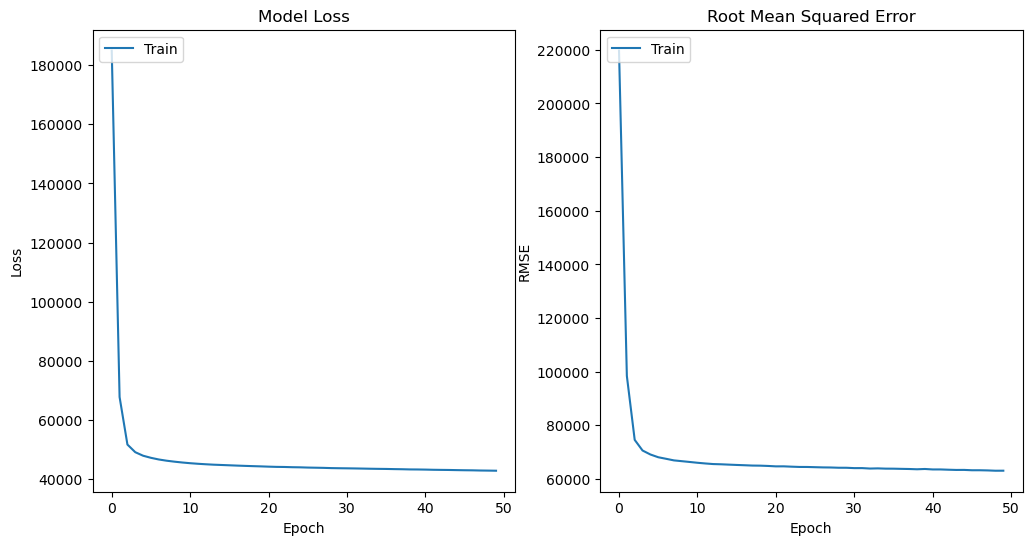

In [21]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'])
plt.title('Root Mean Squared Error')
plt.ylabel('RMSE')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper left')

plt.show()